In [1]:
import yaml
from pathlib import Path
import os
from swiss_roll import RUNS_DIR, DATA_DIR, CONF_DIR
import pandas as pd
from swiss_roll.scheduling import Schedular
import matplotlib.pyplot as plt

In [2]:
guidance_runs_path = RUNS_DIR / 'guidance_models'

print('Guidance run path exists:', guidance_runs_path.exists())

metrics_filename = 'eval_metrics.yaml'

Guidance run path exists: True


In [3]:
training_metrics_list = []
validation_metrics_list = []
successful_runs = []
failed_runs = []  
for root, dirs, _ in guidance_runs_path.walk():
    for dir in dirs:  
        metrics_path = root / dir / metrics_filename
        run_id =  int(dir.split("_")[-1])
        
        try:
            with open(metrics_path, 'r') as f:
                metrics = yaml.load(f, yaml.FullLoader)
        except FileNotFoundError:
            failed_runs.append(run_id)
            continue 

        successful_runs.append(run_id)
        metrics['training_metrics']['run_id'] = run_id
        metrics['validation_metrics']['run_id'] = run_id
        training_metrics_list.append(metrics['training_metrics'])
        validation_metrics_list.append(metrics['validation_metrics'])
print("Successful Runs:", len(successful_runs), "Failed Runs:", len(failed_runs))
training_metrics_dataframe = pd.DataFrame.from_records(training_metrics_list)
validation_metrics_dataframe = pd.DataFrame.from_records(validation_metrics_list)

Successful Runs: 0 Failed Runs: 1008


In [4]:
guidance_confs_path = CONF_DIR / 'guidance_conf'

print('Guidance run path exists:', guidance_runs_path.exists())

conf_list = []
failed_conf_list = []  
for root, _, files in guidance_confs_path.walk():
    for file in files: 
        conf_path = root / file
        with open(conf_path, 'r') as f:
            conf = yaml.load(f, yaml.FullLoader)
       
        run_id =  int(file.split('.')[0]) 
        conf['run_id'] = run_id
       
        if run_id in successful_runs:
            conf_list.append(conf)
        else: 
            failed_conf_list.append(conf)

conf_dataframe = pd.DataFrame.from_records(conf_list)
failed_conf_dataframe = pd.DataFrame.from_records(failed_conf_list)

Guidance run path exists: True


In [5]:
val_conf = validation_metrics_dataframe.merge(conf_dataframe, how='inner', on='run_id')
val_conf = val_conf.sort_values(by='nll')
best_run = val_conf.iloc[0]['run_id']

KeyError: 'run_id'

In [ ]:
val_conf[val_conf['l2_lambda'] < 1][val_conf['tau_t'] == 1000][val_conf['reg_lambda']==1]

/tmp/ipykernel_10005/2737350696.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  val_conf[val_conf['l2_lambda'] < 1][val_conf['tau_t'] == 1000][val_conf['reg_lambda']==1]
/tmp/ipykernel_10005/2737350696.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  val_conf[val_conf['l2_lambda'] < 1][val_conf['tau_t'] == 1000][val_conf['reg_lambda']==1]


,95%_coverage,mse,nll,run_id,ctx_size,l2_lambda,reg_lambda,sigma_t,tau_t,use_ctx
518,0.404288,2.934699,2.860927,508,512,0.1000,1.0,0.100,1000.0,True
812,0.404288,2.935038,2.860976,475,256,0.1000,1.0,0.001,1000.0,True
180,0.404240,2.934881,2.861010,538,512,0.1000,1.0,1.000,1000.0,True
65,0.404193,2.935007,2.861080,595,256,0.1000,1.0,1000.000,1000.0,True
265,0.404193,2.934972,2.861104,565,256,0.1000,1.0,10.000,1000.0,True
499,0.404193,2.935041,2.861157,505,256,0.1000,1.0,0.100,1000.0,True
977,0.404193,2.935034,2.861162,535,256,0.1000,1.0,1.000,1000.0,True
523,0.404146,2.935084,2.861211,598,512,0.1000,1.0,1000.000,1000.0,True
41,0.404146,2.935141,2.861273,478,512,0.1000,1.0,0.001,1000.0,True
456,0.403862,2.935311,2.861490,568,512,0.1000,1.0,10.000,1000.0,True


In [36]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from swiss_roll.utils import load_swissroll, load_model
from swiss_roll.guidance import GuidanceModel, GuidanceBlock 

device = 'cpu'
X, Y, _, _ = load_swissroll(split=False)
X = X[:, [0, 2]]
run_id = 238 
model_path = guidance_runs_path / f"run_{run_id:04d}" / "guidance_model.pth"
model_path ="/home/michaeldodds/Projects/manchester/ethics_ai/context-guided-diffusion/swiss_roll/src/swiss_roll/run_test/guidance_model.pth"

model = load_model(GuidanceModel, model_path)
model.eval()

GuidanceModel(
  (inlayer): GuidanceBlock(
    (layer): Linear(in_features=2, out_features=32, bias=True)
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (midlayer): ModuleList(
    (0-1): 2 x GuidanceBlock(
      (layer): Linear(in_features=32, out_features=32, bias=True)
      (dropout): Dropout(p=0.2, inplace=False)
    )
  )
  (outlayer): Linear(in_features=32, out_features=2, bias=True)
)

In [37]:
preds, _ = model(X)
pred_means = preds[:, :1]
pred_logvar = preds[:, 1:]
pred_means = pred_means.to(device).detach().numpy()
pred_logvar = pred_logvar.to(device).detach().numpy()

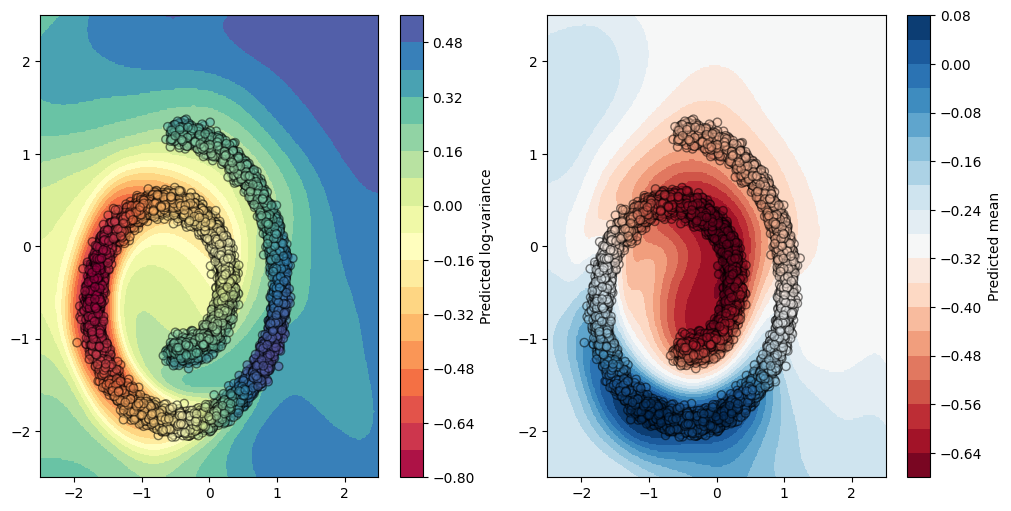

In [38]:
n = 300
x1_lin = x2_lin = np.linspace(-2.5, 2.5, n)
XX, YY = np.meshgrid(x1_lin, x2_lin)
grid = np.stack([XX.ravel(), YY.ravel()], axis=1)
with torch.no_grad():
    inp = torch.from_numpy(grid).float().to(device)
    pred, _ = model(inp)
mu = pred[:, :1]
logvar = pred[:, 1:]
ZZ = np.round(logvar.cpu().numpy().reshape(XX.shape), 2)
ZZ_mu = np.round(mu.cpu().numpy().reshape(XX.shape), 2)

fig, ax = plt.subplots(1, 2, figsize=(12,6))
cf = ax[0].contourf(XX, YY, ZZ, levels=20, cmap='Spectral')
cf2 = ax[1].contourf(XX, YY, ZZ_mu, levels=20, cmap='RdBu')
fig.colorbar(cf, ax=ax[0], label='Predicted log-variance') 
fig.colorbar(cf2, ax=ax[1], label='Predicted mean')

idx = torch.randperm(len(X))[: 10_000]
ax[0].scatter(X[idx, 0], X[idx, 1], c=pred_logvar[idx], alpha=0.5, edgecolors='black', cmap='Spectral')
ax[1].scatter(X[idx, 0], X[idx, 1], c=pred_means[idx], alpha=0.5, edgecolors='black', cmap='RdBu')
